# 가장 많이/적게(수량/금액) 팔린 제품
- 판매 table을 활용하여 수량 기준과 금액 기준으로 많이
팔린 제품과 적게 팔린 제품 분석.
- 실제 실무라면, 예상대로 판매가 이루어지고 있는지, 어떤
제품에 집중해야 하는지 등등 분석할 수 있음.

In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [12]:
import os
from dotenv import load_dotenv
import mysql.connector

load_dotenv()

# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
    host=os.getenv('DB_HOST', 'localhost'),
    user=os.getenv('DB_USER', 'root'),
    password=os.getenv('DB_PASSWORD', ''),
    database=os.getenv('DB_NAME', 'sys')
)

In [22]:
# 가장 잘 팔리는 제품 분석 쿼리 실행
# 각 제품의 총 판매량(total_quantity)를 계산하고, 가장 많이 팔린 제품을 상위 5개 출력
top_products_query = """
 SELECT
 	od.productCode,
    p.productName,
 	sum(od.quantityOrdered) AS total_quantity
 FROM products AS p
 JOIN orderdetails AS od
 	ON od.productCode = p.productCode
 JOIN orders AS o
 WHERE o.status IN ('Shipped', 'resolved')
 GROUP BY productCode
 ORDER BY total_quantity desc
 LIMIT 5

"""

In [23]:
# 가장 안 팔리는 제품 분석 쿼리 실행
bottom_products_query = """
 SELECT
 	od.productCode,
    p.productName,
 	sum(od.quantityOrdered) AS total_quantity
 FROM products AS p
 JOIN orderdetails AS od
 	ON od.productCode = p.productCode
 JOIN orders AS o
 WHERE o.status IN ('Shipped', 'resolved')
 GROUP BY productCode
 ORDER BY total_quantity
 LIMIT 5

"""

In [24]:
# SQL 쿼리 실행 및 결과 DataFrame으로 변환
top_products_df = pd.read_sql_query(top_products_query, conn)
bottom_products_df = pd.read_sql_query(bottom_products_query, conn)

In [25]:
# 연결 종료
conn.close()

## 가장 많이 (수량) 팔린 제품

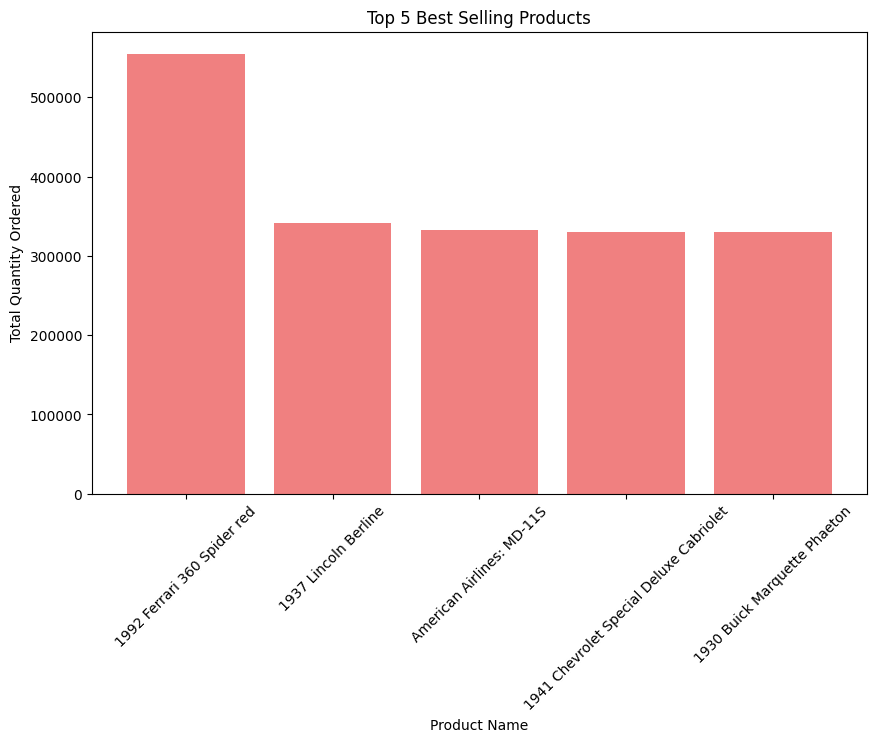

In [26]:
# 가장 잘 팔리는 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(top_products_df['productName'], top_products_df['total_quantity'], color='lightcoral')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Ordered')
plt.title('Top 5 Best Selling Products')
plt.xticks(rotation=45)
plt.show()

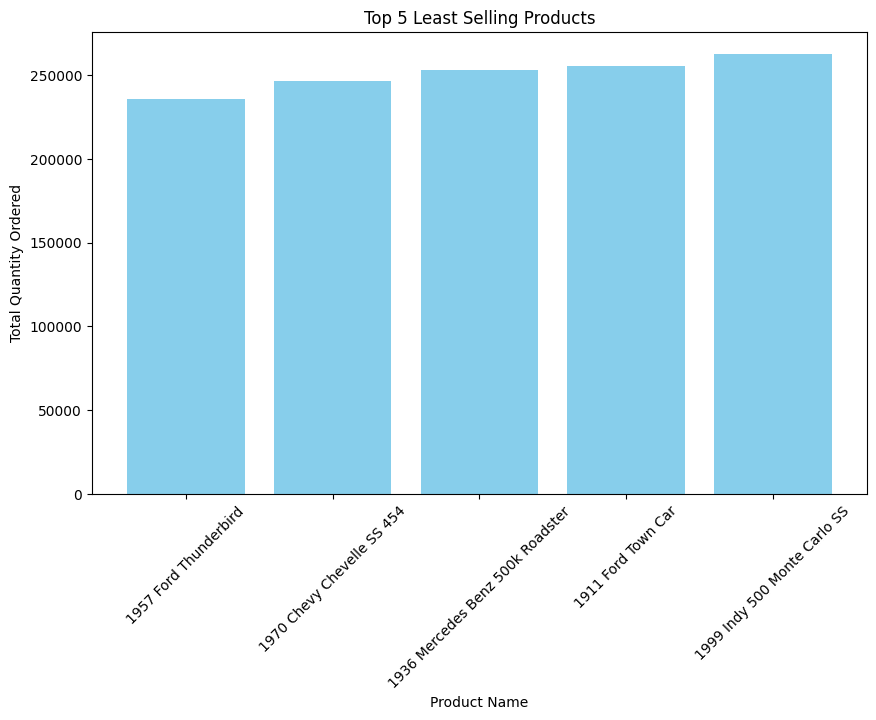

In [27]:
# 가장 안 팔리는 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(bottom_products_df['productName'], bottom_products_df['total_quantity'], color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Ordered')
plt.title('Top 5 Least Selling Products')
plt.xticks(rotation=45)
plt.show()

## 가장 많이 (금액) 팔린 제품

In [28]:
import os
from dotenv import load_dotenv
import mysql.connector

load_dotenv()

# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
    host=os.getenv('DB_HOST', 'localhost'),
    user=os.getenv('DB_USER', 'root'),
    password=os.getenv('DB_PASSWORD', ''),
    database=os.getenv('DB_NAME', 'sys')
)

In [33]:
# 가장 많이 팔린 제품 분석 쿼리 실행
# 각 제품의 총 매출(total_sales)을 계산하고, 가장 높은 매출을 기록한 상위 5개 제품을 찾는 쿼리
top_products_query = """
 
 SELECT
 	od.productCode,
    p.productName,
 	sum(od.quantityOrdered) * p.buyPrice AS total_sales
 FROM products AS p
 JOIN orderdetails AS od
 	ON od.productCode = p.productCode
 JOIN orders AS o
 WHERE o.status IN ('Shipped', 'resolved')
 GROUP BY productCode
 ORDER BY total_sales desc
 LIMIT 5
"""

In [34]:
# 가장 적게 팔린 제품 분석 쿼리 실행
bottom_products_query = """
 SELECT
 	od.productCode,
    p.productName,
 	sum(od.quantityOrdered) * p.buyPrice AS total_sales
 FROM products AS p
 JOIN orderdetails AS od
 	ON od.productCode = p.productCode
 JOIN orders AS o
 WHERE o.status IN ('Shipped', 'resolved')
 GROUP BY productCode
 ORDER BY total_sales
 LIMIT 5
"""

In [35]:
# SQL 쿼리 실행 및 결과 DataFrame으로 변환
top_products_df = pd.read_sql_query(top_products_query, conn)
bottom_products_df = pd.read_sql_query(bottom_products_query, conn)

In [ ]:
# 연결 종료
conn.close()

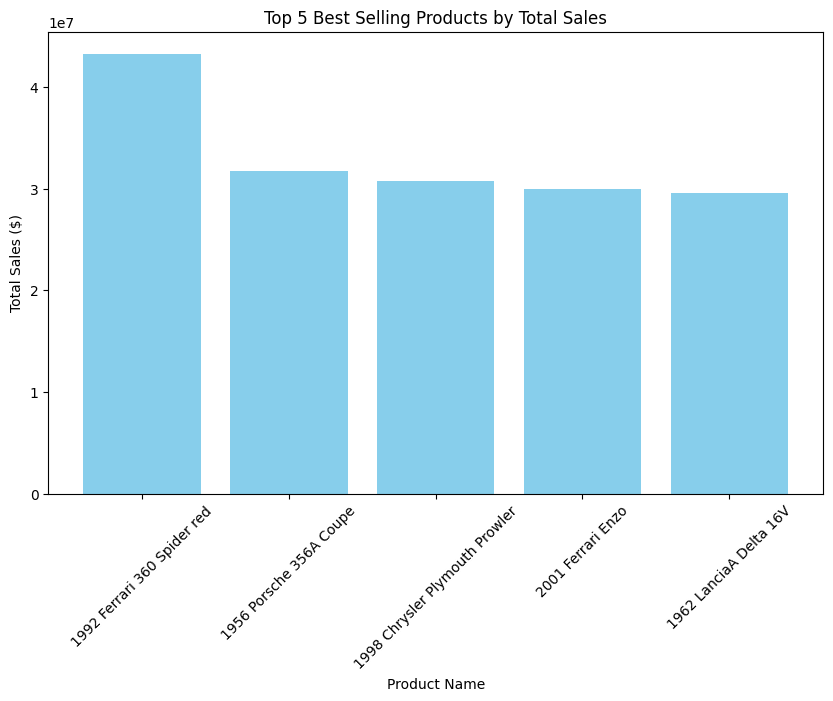

In [36]:
# 가장 많이 팔린 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(top_products_df['productName'], top_products_df['total_sales'], color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Sales ($)')
plt.title('Top 5 Best Selling Products by Total Sales')
plt.xticks(rotation=45)
plt.show()

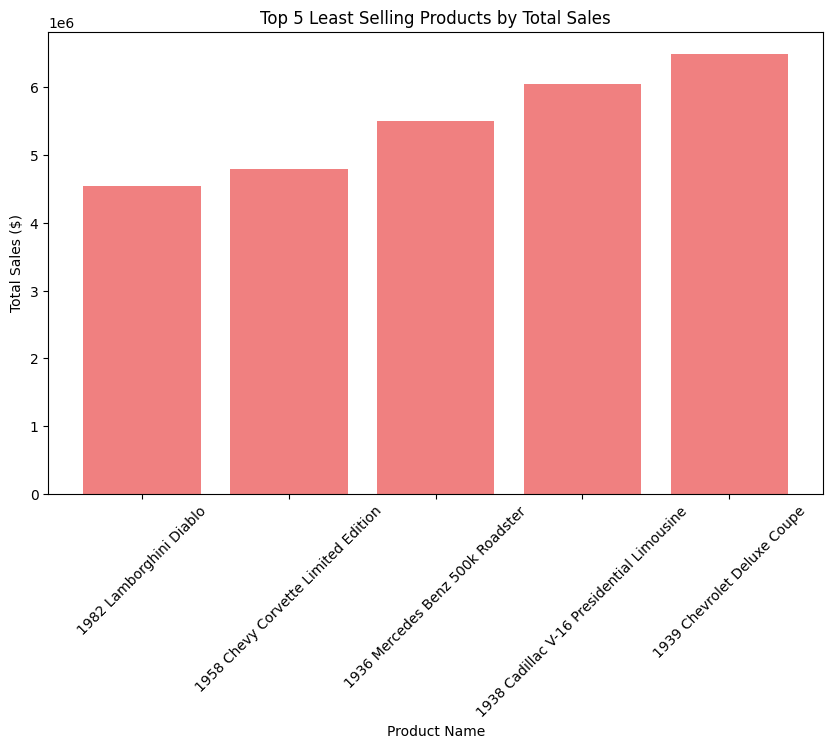

In [37]:
# 가장 적게 팔린 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(bottom_products_df['productName'], bottom_products_df['total_sales'], color='lightcoral')
plt.xlabel('Product Name')
plt.ylabel('Total Sales ($)')
plt.title('Top 5 Least Selling Products by Total Sales')
plt.xticks(rotation=45)
plt.show()

- 결과를 분석해보면, 수량으로 많이/적게 팔린 제품과 금액으로 많이/적게 팔린 제품이 다르며, 회사의 주력상품의 매출이 잘 나오고 있는지, 마케팅이 잘 되고 있는지 등을 분석하고 향후 방향성을 제시
